## Anomaly Detection in Credit Card Fraud

**Prepared By: Olumide Johnson Ikumapayi**

### Project Overview

This project focuses on detecting fraudulent credit card transactions using machine learning techniques, particularly anomaly detection methods. Given the rarity of fraudulent transactions compared to legitimate ones, the dataset is highly imbalanced, making anomaly detection a suitable approach. 

**Problem Statement**: To predict whether a given transaction is either fraudulent or legitimate, based on input features (like Time, Amount, and V1 to V28).

**Project Objective**

To develop and evaluate machine learning models capable of accurately identifying fraudulent credit card transactions from highly imbalanced datasets by leveraging both supervised and unsupervised anomaly detection techniques, with the goal of minimizing false negatives while maintaining a high detection rate to support secure and efficient financial operations.

**About the Dataset**

The dataset employed originates from a Kaggle competition and encompasses credit card transactions made by European cardholders over two days in September 2013. It comprises a total of 284,807 transactions, with 492 instances labeled as fraudulent, highlighting the significant class imbalance.•	The dataset can be downloaded from Kaggle public repository: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud.

**Please Note** :This project is a **CLASSIFICATION** problem — specifically, a binary classification problem.


The flow of the **Credit Card Fraud** dataset is as follows:

1. [Project Setup & Libraries](#Project-Setup-&-Libraries)
2. [Data Acquisition & Initial Inspection](#Data-Acquisition-&-Initial-Inspection)
3. [Data Cleaning & Missing Values](#Data-Cleaning-&-Missing-Values)
4. [Description of Dataset](#Description-of-Dataset)
5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
6. [Correlation Analysis](#Correlation-Analysis)
7. [Feature Engineering & Preprocessing](#Feature-Engineering-&-Preprocessing)
8. [Balancing the Dataset Using SMOTE](#Balancing-the-Dataset-Using-SMOTE)
9. [Machine Learning Models](#Machine-Learning-Models)
10.[Summary and Conclusion](#Summary-and-Conclusion)

### Project Setup & Libraries

In [1]:
# Standard Library
import math
import re
import warnings

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific / Statistics
from scipy.stats import boxcox, zscore

# Machine Learning - Scikit-learn
from sklearn import datasets, metrics, model_selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay, plot_roc_curve

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Statistical Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Model Persistence
import joblib

# Warning Settings
warnings.filterwarnings('ignore')

### Data Acquisition & Initial Inspection

#### Loading the dataset from the Database

In [2]:
df_CreditCard_fraudDetection = pd.read_csv('creditcard.csv')
df_CreditCard_fraudDetection.head(30)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [3]:
df_CreditCard_fraudDetection.tail(30)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284777,172764.0,2.079137,-0.028723,-1.343392,0.358000,-0.045791,-1.345452,0.227476,-0.378355,0.665911,...,0.235758,0.829758,-0.002063,0.001344,0.262183,-0.105327,-0.022363,-0.060283,1.00,0
284778,172764.0,-0.764523,0.588379,-0.907599,-0.418847,0.901528,-0.760802,0.758545,0.414698,-0.730854,...,0.003530,-0.431876,0.141759,0.587119,-0.200998,0.267337,-0.152951,-0.065285,80.00,0
284779,172766.0,1.975178,-0.616244,-2.628295,-0.406246,2.327804,3.664740,-0.533297,0.842937,1.128798,...,0.086043,0.543613,-0.032129,0.768379,0.477688,-0.031833,0.014151,-0.066542,25.00,0
284780,172766.0,-1.727503,1.108356,2.219561,1.148583,-0.884199,0.793083,-0.527298,0.866429,0.853819,...,-0.094708,0.236818,-0.204280,1.158185,0.627801,-0.399981,0.510818,0.233265,30.00,0
284781,172766.0,-1.139015,-0.155510,1.894478,-1.138957,1.451777,0.093598,0.191353,0.092211,-0.062621,...,-0.191027,-0.631658,-0.147249,0.212931,0.354257,-0.241068,-0.161717,-0.149188,13.00,0
284782,172767.0,-0.268061,2.540315,-1.400915,4.846661,0.639105,0.186479,-0.045911,0.936448,-2.419986,...,-0.263889,-0.857904,0.235172,-0.681794,-0.668894,0.044657,-0.066751,-0.072447,12.82,0
284783,172768.0,-1.796092,1.929178,-2.828417,-1.689844,2.199572,3.123732,-0.270714,1.657495,0.465804,...,0.271170,1.145750,0.084783,0.721269,-0.529906,-0.240117,0.129126,-0.080620,11.46,0
284784,172768.0,-0.669662,0.923769,-1.543167,-1.560729,2.833960,3.240843,0.181576,1.282746,-0.893890,...,0.183856,0.202670,-0.373023,0.651122,1.073823,0.844590,-0.286676,-0.187719,40.00,0
284785,172768.0,0.032887,0.545338,-1.185844,-1.729828,2.932315,3.401529,0.337434,0.925377,-0.165663,...,-0.266113,-0.716336,0.108519,0.688519,-0.460220,0.161939,0.265368,0.090245,1.79,0
284786,172768.0,-2.076175,2.142238,-2.522704,-1.888063,1.982785,3.732950,-1.217430,-0.536644,0.272867,...,2.016666,-1.588269,0.588482,0.632444,-0.201064,0.199251,0.438657,0.172923,8.95,0


**Inspecting shape, column, types, missing values and Other Basic Statistics**

In [4]:
# Checking the dataset dimension
df_CreditCard_fraudDetection.shape

(284807, 31)

The dataset contains 284,807 rows and 31 columns.Of which 1 is target variable and the remaining 30 are independent varbiables.


**Dataset Characteristics**:

* **Anonymization**: Due to confidentiality concerns, most features have been transformed using Principal Component Analysis (PCA), resulting in features named V1 through V28. 

**Additional Features**:
*   **Time**: Represents the seconds elapsed between each transaction and the first transaction in the dataset.
* **Amount**: Denotes the transaction amount.
*  **Class**: Binary label indicating the nature of the transaction: (0) for legitimate and (1) for fraudulent. 


In [5]:
# Check column for creditcard fraud data
df_CreditCard_fraudDetection.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
# Checking the list of columns for dataset
df_CreditCard_fraudDetection.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [7]:
# checking the types of columns
df_CreditCard_fraudDetection.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

There three(3) different types of data(int64,float64 and object) present in the dataset.

In [8]:
# Checking the column info
df_CreditCard_fraudDetection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

As shown above,there are no null values present in this dataset.

**Attribute Information**

The dataset consists of 31 features, detailed as follows:

**Input Variables**:

* **Time**: Elapsed time in seconds between the transaction and the first transaction in the dataset.
* **V1 to V28**: Resultant features from PCA transformation, ensuring confidentiality of the original attributes.
* **Amount**: Transaction amount, which can be used for scaling and modelling. 

**Output Variable**:
* **Class**: Target variable indicating the transaction status: (0) : Legitimate/Non Fraudulent transaction, Or (1): Fraudulent transaction


### Data Cleaning & Missing Values

**Handling null, missing and inconsistent data**

In [9]:
# checking null values
df_CreditCard_fraudDetection.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
# Checking each column for no of unique values 
df_CreditCard_fraudDetection.nunique().to_frame("No.of unique values")

,No.of unique values
Time,124592
V1,275663
V2,275663
V3,275663
V4,275663
V5,275663
V6,275663
V7,275663
V8,275663
V9,275663


<AxesSubplot:>

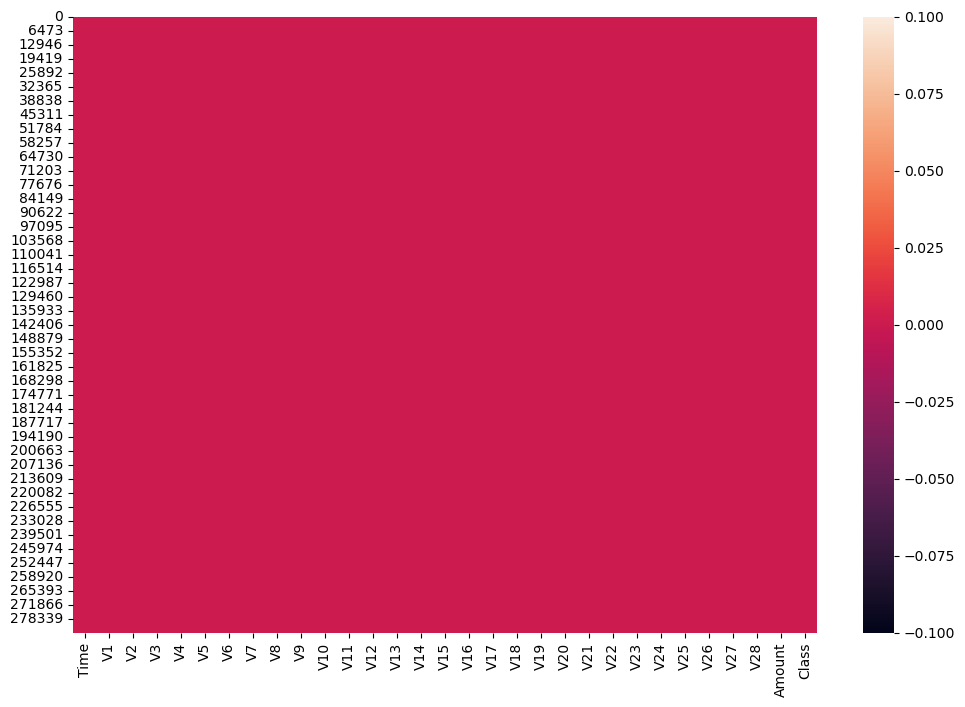

In [11]:
# Visualizing using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_CreditCard_fraudDetection.isnull())

This heatmap indicates that the dataset has no missing values across all features. The uniform color throughout the plot shows that every column, including Time, Amount, the anonymized variables V1 to V28, and the target variable Class, is entirely complete.

### Description of Dataset

In [12]:
# Lets Describe the numerical columns of the dataframe 
df_CreditCard_fraudDetection.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**This is the statistical information of the numerical columns.Although the summary of the dataset has some negative/invalid values present and does not look perfect.**

from the above description, we can observe the following-:
1. The counts of all the columns are the same which means there are no missing values in the dataset.
2. The mean value is greater than the median(50%) in some columns which means the data is skewed to right in these column.
3. The data in some of the columns also have mean value less than median which means the data is skewed to left.
4. By summarizing the data we can observe the differences between the 75% and max an indication that there are outliers present in the data.
5. We can also notice the Standard deviation,min,25% percentile from this describe method.  

In [13]:
# Lets also check the statistical distribution for numerical features
df_CreditCard_fraudDetection.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,3.918649e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,5.682686e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-8.761736e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.811118e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,-1.552103e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,2.040130e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-1.698953e-15,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,-1.893285e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-3.147640e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [14]:
# Lets select only numeric columns
num_cols = df_CreditCard_fraudDetection.select_dtypes(include=['number']).columns
num_cols

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

### Exploratory Data Analysis (EDA)


**Univariate analysis**

In [15]:
# Checking the list of counts of target
df_CreditCard_fraudDetection["Class"].unique()

array([0, 1], dtype=int64)

In [16]:
# Checking the unique values in target column
df_CreditCard_fraudDetection['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

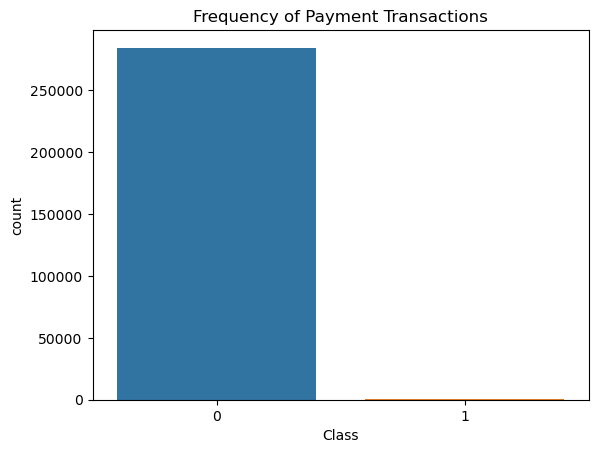

Number of legitimate transactions:  284315
Number of fraudulent transactions:  492


In [17]:
fraudulent_transaction = df_CreditCard_fraudDetection.loc[df_CreditCard_fraudDetection.Class == 1] 
nonfraud_transaction = df_CreditCard_fraudDetection.loc[df_CreditCard_fraudDetection.Class == 0]

sns.countplot(x="Class",data=df_CreditCard_fraudDetection)
plt.title("Frequency of Payment Transactions")
plt.show()
print("Number of legitimate transactions: ",nonfraud_transaction.Class.count())
print("Number of fraudulent transactions: ",fraudulent_transaction.Class.count())

 As showned above the Credit Card dataset is imbalanced looking at the frequency and bar chart representations. Imballanced data's have certain level of biases and threats to the Machine Learning models.
 We will use an Oversampling measure called SMOTE (Synthetic Minority Over-sampling Technique) to create new data points from minority class using the neighbour instances to generate similar samples.

In [18]:
print((df_CreditCard_fraudDetection.groupby('Class')['Amount'].sum()).reset_index().rename(
    columns={'Class':'Fraudulent/Non Fraudulent','Amount' : 'Amount Volume'}).sort_values(
    by='Amount Volume'))

   Fraudulent/Non Fraudulent  Amount Volume
1                          1       60127.97
0                          0    25102462.04


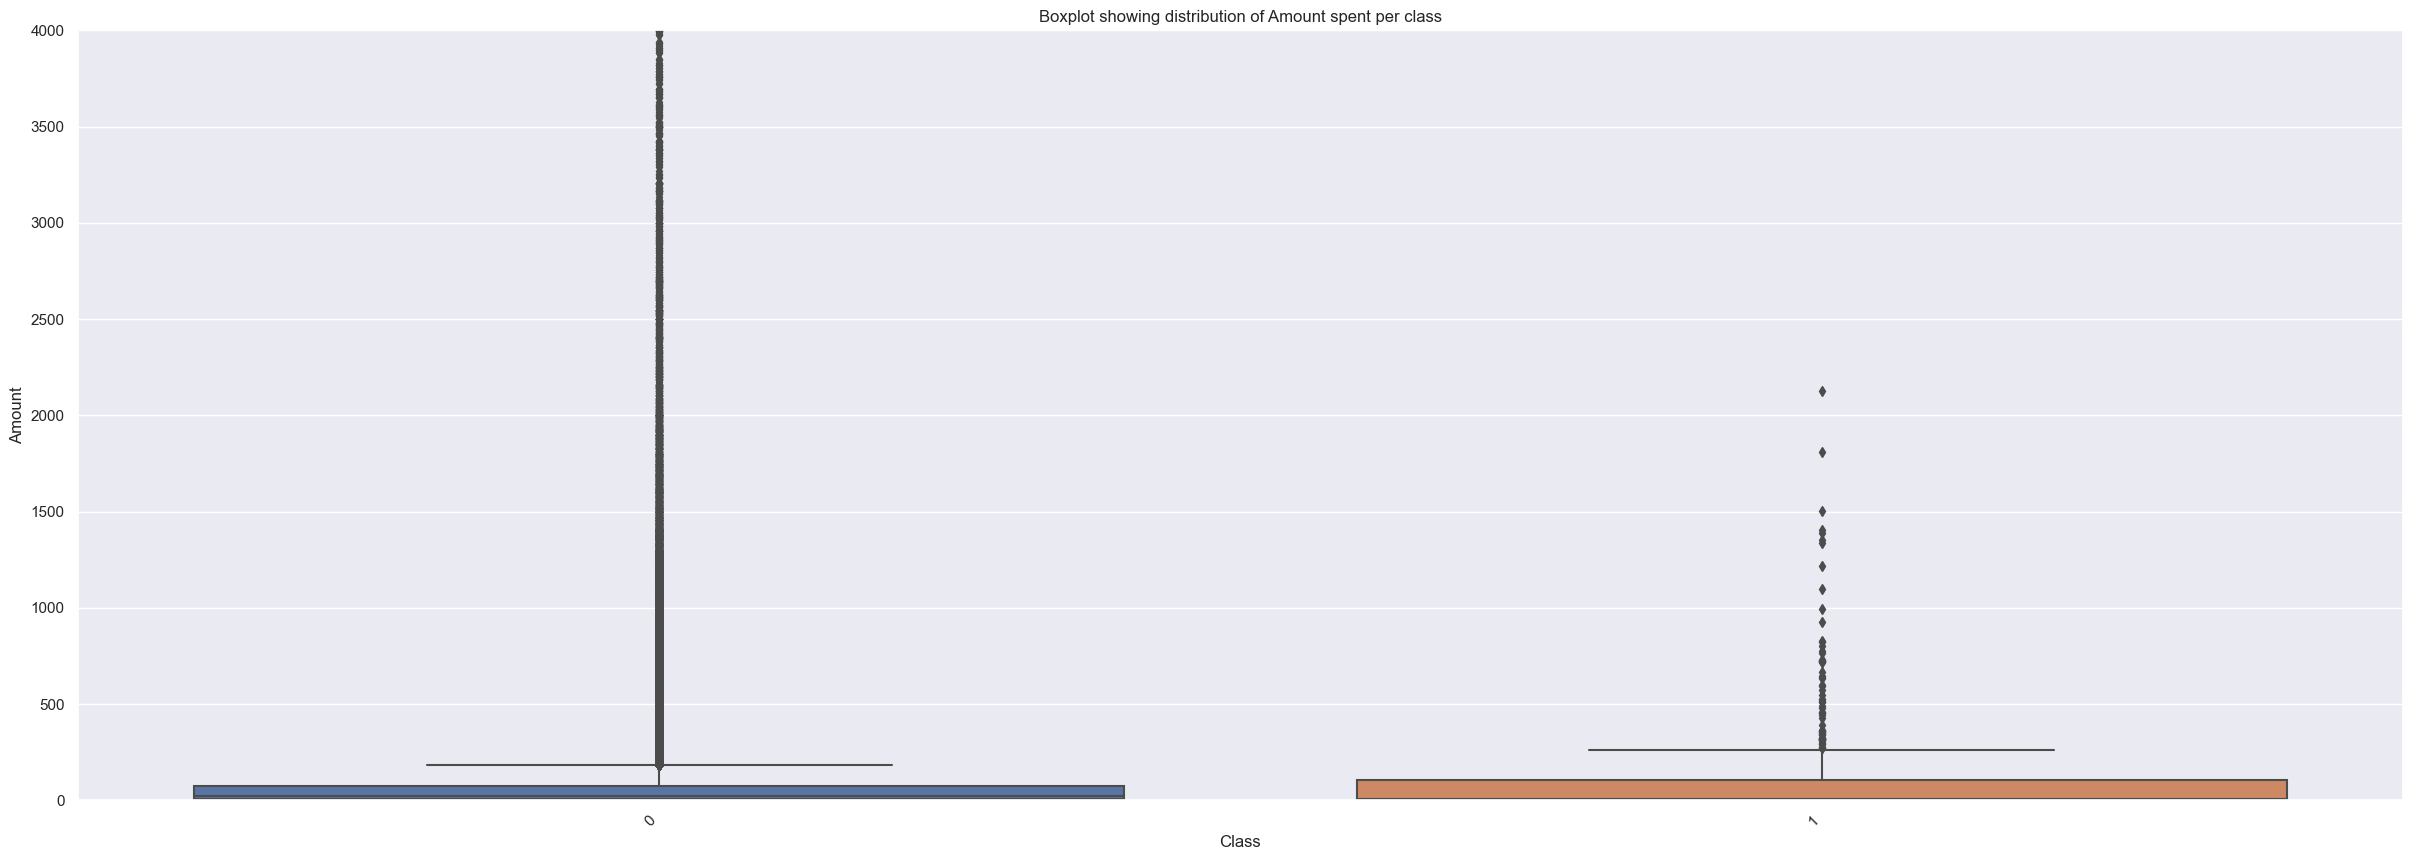

In [19]:
# Lets Plot histograms of the amounts in fraud and non-fraud data 

plt.figure(figsize=(30,10))
sns.set(style="darkgrid")
distfraud = sns.boxplot(x=df_CreditCard_fraudDetection.Class,y=df_CreditCard_fraudDetection.Amount, orient='v');
plt.title("Boxplot showing distribution of Amount spent per class"),
plt.ylim(0,4000)
distfraud.set_xticklabels(distfraud.get_xticklabels(), rotation=45, horizontalalignment='right')

plt.show()

This boxplot suggests that **fraudulent transactions tend to have a higher median transaction amount and greater variability** than legitimate transactions. Both classes contain many outliers, but the spread for fraud cases appears wider, indicating that fraudulent payments may occur across a broader range of amounts. 


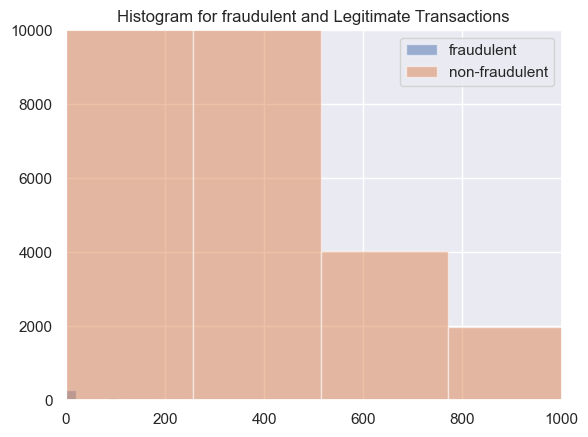

In [20]:
# We Plot histograms of the amounts in fraud and non-fraud data 

plt.hist(fraudulent_transaction.Amount, alpha=0.5, label='fraudulent',bins=100)
plt.hist(nonfraud_transaction.Amount, alpha=0.5, label='non-fraudulent',bins=100)
plt.title("Histogram for fraudulent and Legitimate Transactions")
plt.ylim(0,10000)
plt.xlim(0,1000)
plt.legend()
plt.show()

The above histogram shows that both fraudulent and non-fraudulent transactions are concentrated at **lower transaction amounts**, with frequency declining as the amount increases. In all, Fraud cases appear much fewer, which is consistent with the strong class imbalance in the dataset. This suggests that most transactions, regardless of class, occur at relatively small amounts, while transactions involving larger amounts occur less frequently.

**Histogram Plots for each Feature variables**

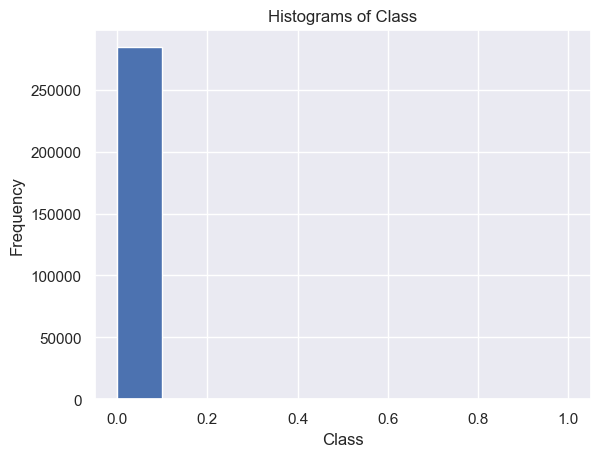

In [21]:
# Histogram for Class
plt.hist(df_CreditCard_fraudDetection['Class'])
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title('Histograms of Class')
plt.show()

The above histogram confirms that the dataset is **heavily dominated by class 0**, while **class 1 appears only in a very small proportion**. This highlights a severe class imbalance, meaning fraudulent transactions are rare compared to legitimate ones. This imbalance would be handled with care to avoid biased predictions toward the majority class.


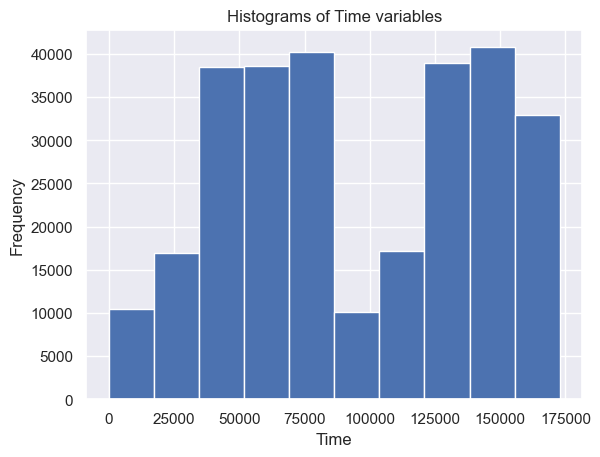

In [22]:
# Histogram for the Time variable
plt.hist(df_CreditCard_fraudDetection['Time'])
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title('Histograms of Time variables')
plt.show()

This histogram shows that transaction activity is spread across the recorded time period, though not perfectly evenly. Some time intervals contain higher volumes of transactions than others, suggesting fluctuations in transaction frequency over time.


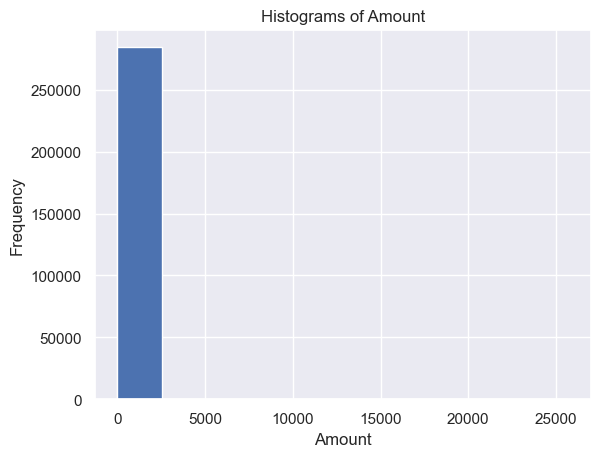

In [23]:
# Histogram for Amount
plt.hist(df_CreditCard_fraudDetection['Amount'])
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title('Histograms of Amount')
plt.show()

This histogram shows that **most transactions are concentrated at very low amounts**, while only a small number occur at much higher values thereby creating a very strong right-skewed distribution,ence,the 'Amount' feature contains lots of low-value transactions with a few extreme high-value outliers.


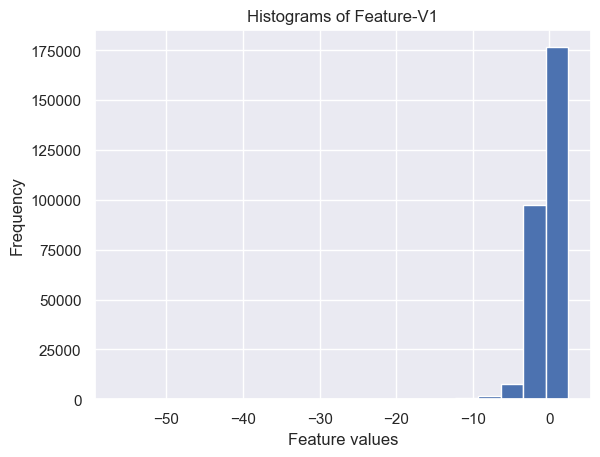

In [24]:
# Histogram for V1
plt.hist(df_CreditCard_fraudDetection[['V1']].values, bins=20)
plt.xlabel('Feature values')
plt.ylabel('Frequency')
plt.title('Histograms of Feature-V1')
plt.show()

The histogram for V1 shows that most values are clustered within a narrow range near the center, while a few observations extend far into the negative(-ve) side. This indicates that the feature is left-skewed and contains some extreme negative(-ve) outliers.

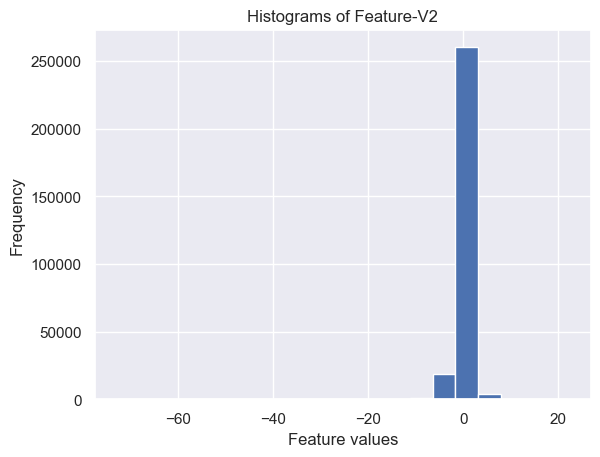

In [25]:
# Histogram for V2
plt.hist(df_CreditCard_fraudDetection[['V2']].values, bins=20)
plt.xlabel('Feature values')
plt.ylabel('Frequency')
plt.title('Histograms of Feature-V2')
plt.show()

The histogram for **V2** shows that most values are tightly concentrated around the center, with relatively few observations spread far from the main cluster. The feature appears to have a **slight right skew**, though it remains strongly centered near zero for most transactions. Generally, the **V2** is dominated by common mid-range values, with only a small number of extreme observations.

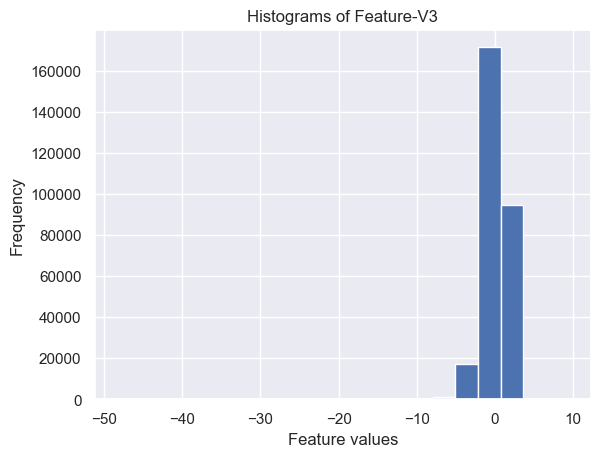

In [26]:
# Histogram for V3
plt.hist(df_CreditCard_fraudDetection[['V3']].values, bins=20)
plt.xlabel('Feature values')
plt.ylabel('Frequency')
plt.title('Histograms of Feature-V3')
plt.show()

The histogram for V3 shows that most values are concentrated near the center, especially around values close to zero, while a smaller number extend further into the negative range. This suggests that the feature is slightly left-skewed and includes some negative(-ve) outliers.

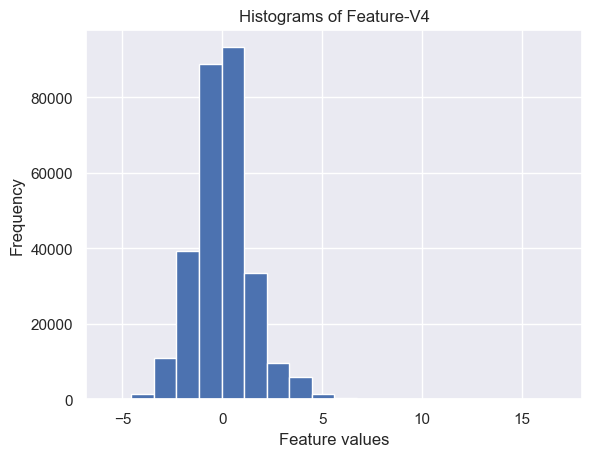

In [27]:
# Histogram for V4
plt.hist(df_CreditCard_fraudDetection[['V4']].values, bins=20)
plt.xlabel('Feature values')
plt.ylabel('Frequency')
plt.title('Histograms of Feature-V4')
plt.show()

The histogram for **V4** appears approximately **bell-shaped and centered near zero**, with most values concentrated in the middle range. There is a slight extension toward higher positive values, suggesting a **mild right skew**, but extreme values are relatively limited. In all, the 'V4' shows a fairly compact distribution when compared with some of the other features.


**Multivariate Analysis**

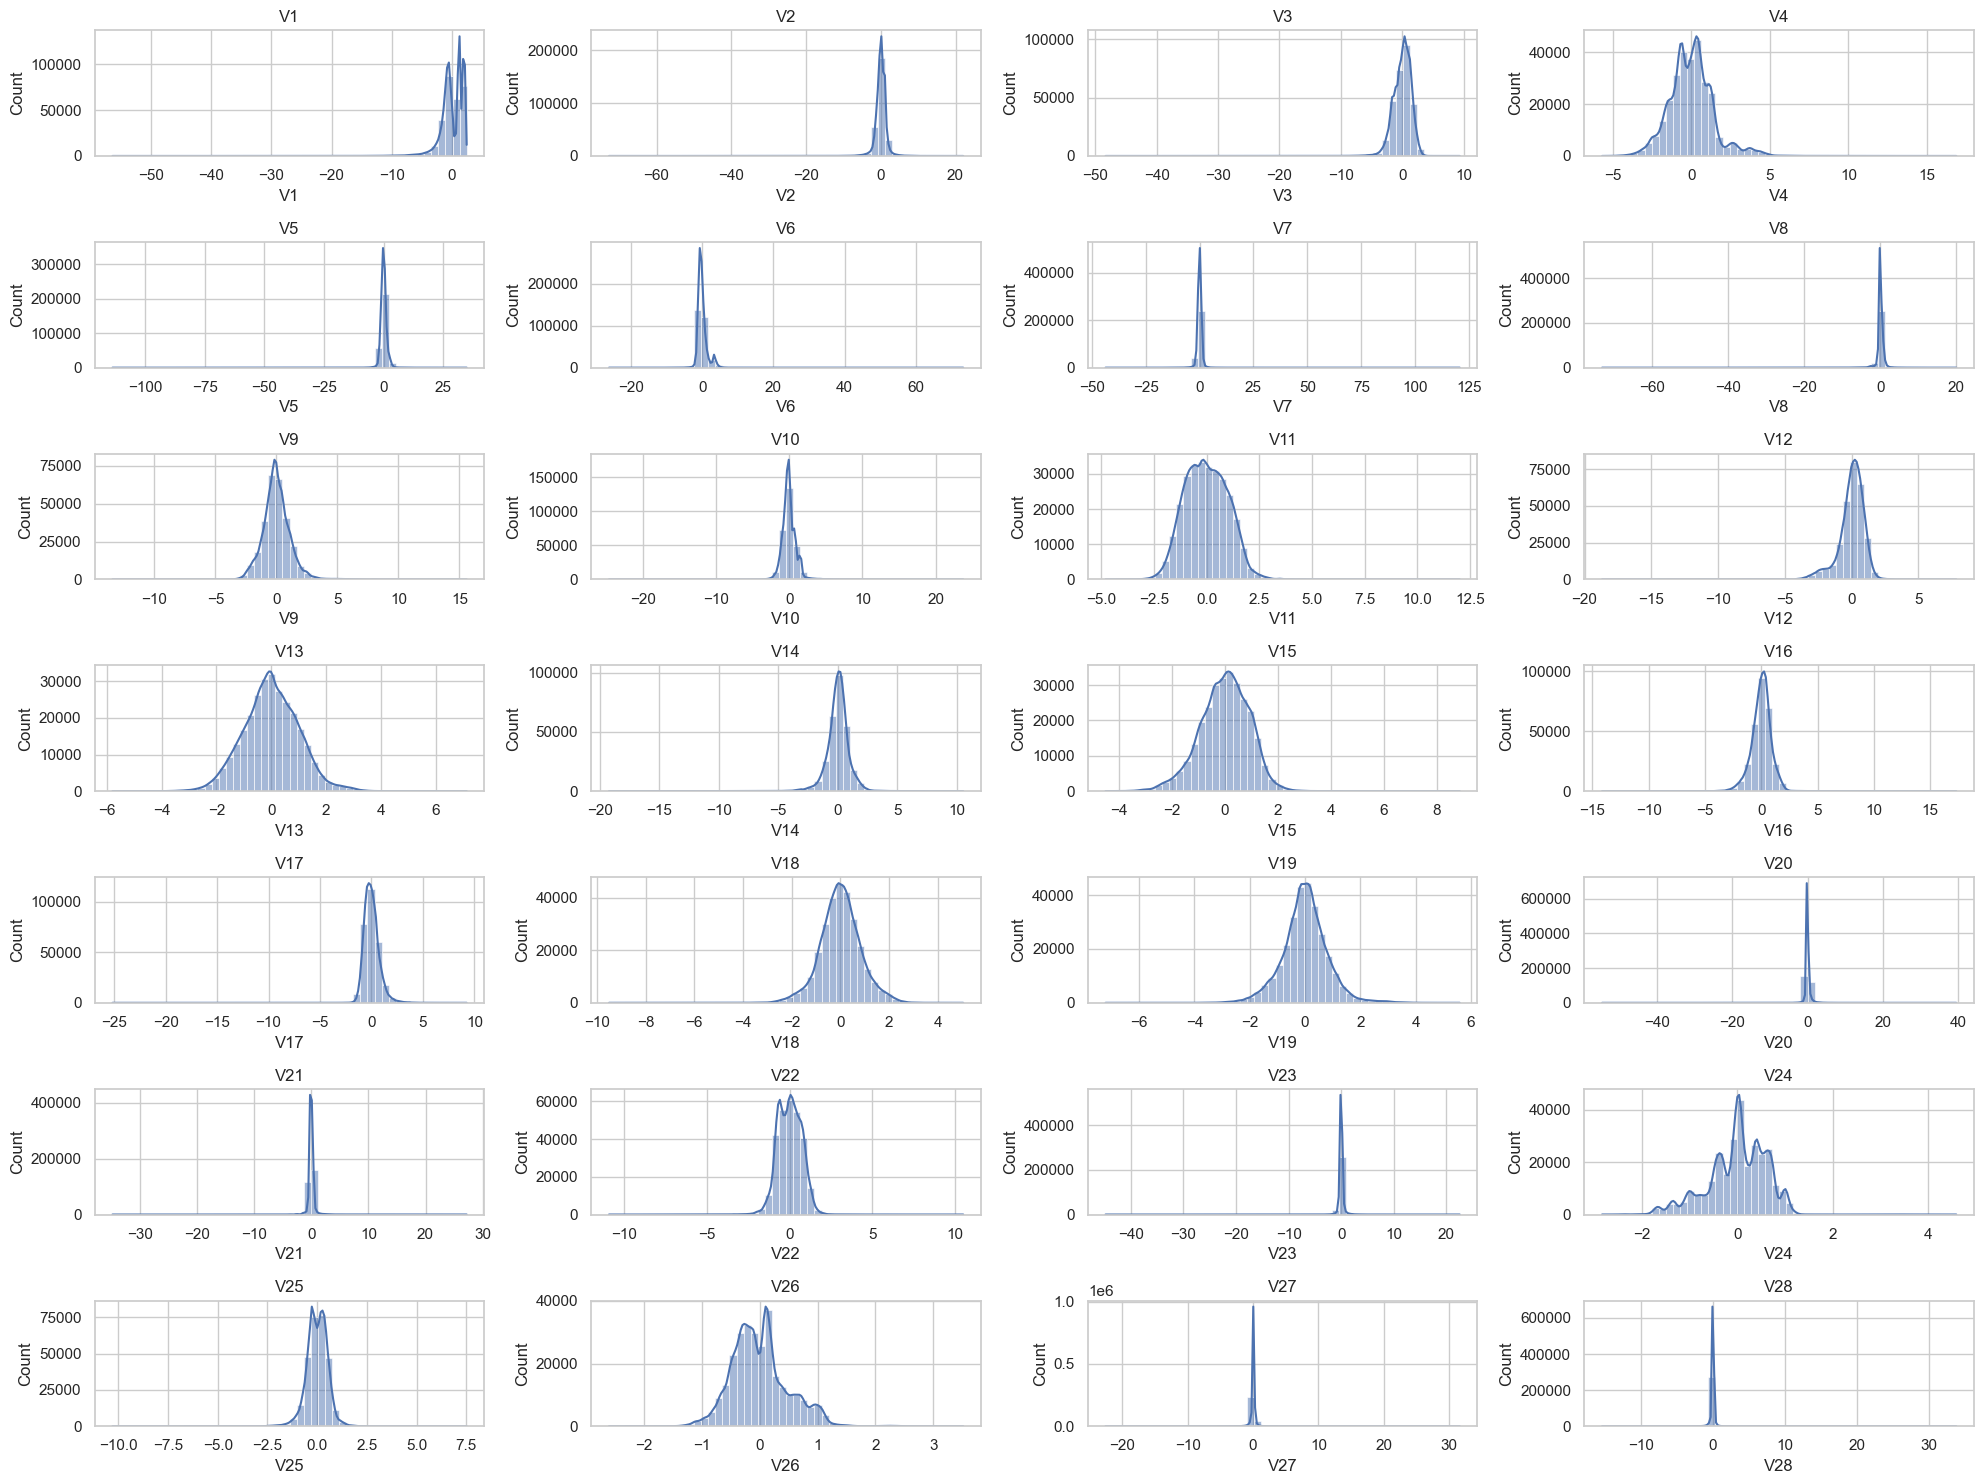

In [28]:
# Distribution of numeric variables for V1 To V28
sns.set(style="whitegrid")
plt.figure(figsize=(20, 15))
v_columns = [f"V{i}" for i in range(1, 29)]
for i, col in enumerate(v_columns, 1):
    plt.subplot(7, 4, i)  # 7 rows × 4 cols grid
    sns.histplot(df_CreditCard_fraudDetection[col], kde=True, bins=50)
    plt.title(col)

plt.tight_layout()
plt.show()

The multivariate distribution plots show that features **'V1' to 'V28'** exhibit varied distribution shapes, spreads, and skewness, capturing transaction behavior across multiple dimensions. While many of the variables are centered near zero(0), their distributions differ in concentration and tail behavior, with some appearing approximately symmetric and others showing noticeable skewness or extreme values. These differences suggest that the feature space is heterogeneous and contains both stable patterns and unusual observations. The presence of long tails and outliers are particularly important for **fraud detection**, since fraudulent transactions are often rare and behaviorally distinct.


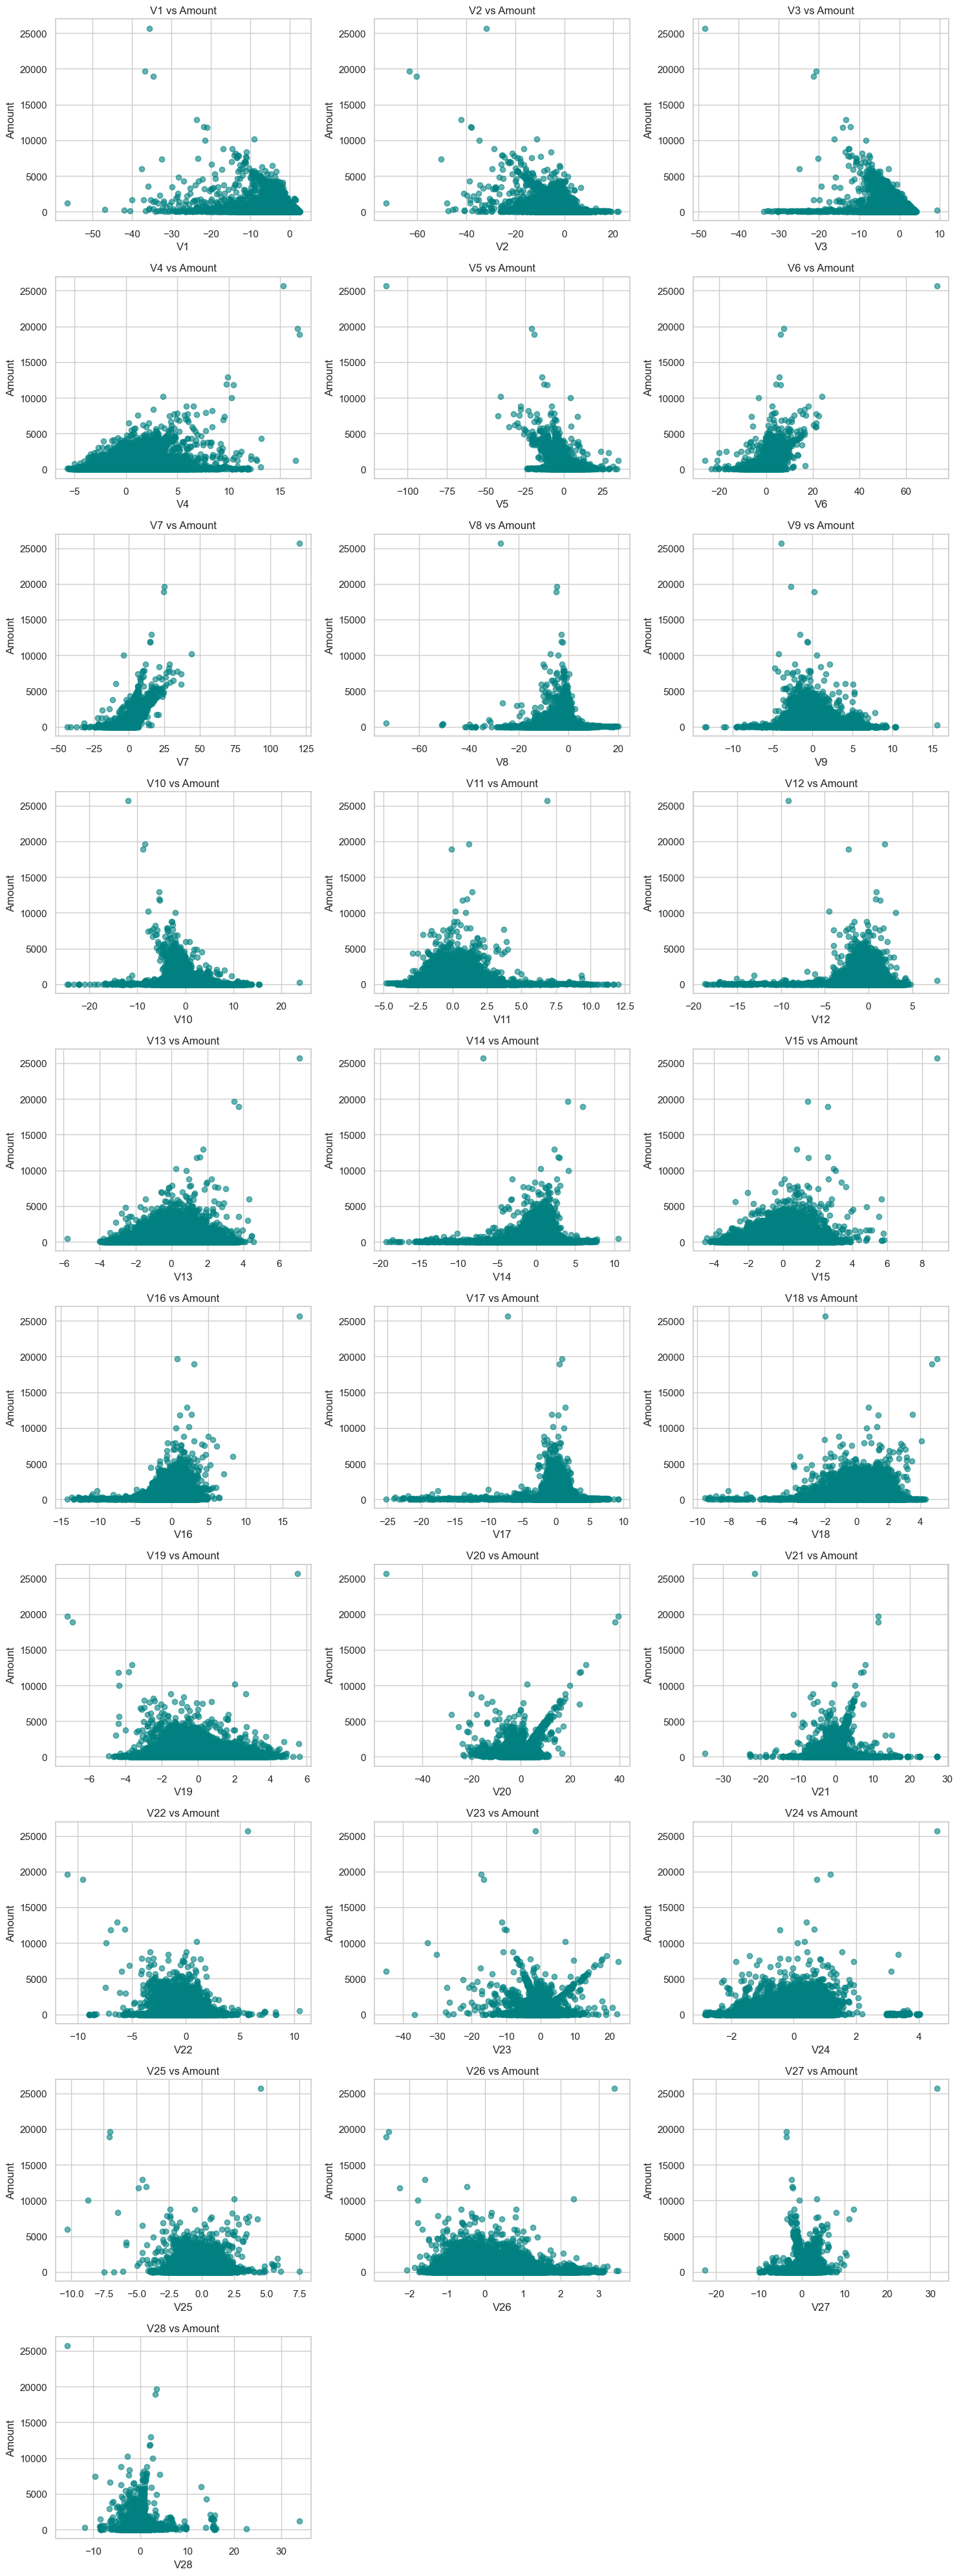

In [29]:
features = [f"V{i}" for i in range(1, 29)]  # range(1, 29) for V1–V28

n_features = len(features)
n_cols = 3  # number of columns in the grid
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(df_CreditCard_fraudDetection[col], df_CreditCard_fraudDetection["Amount"], color='teal', alpha=0.6)
    plt.title(f"{col} vs Amount")
    plt.xlabel(col)
    plt.ylabel("Amount")

plt.tight_layout()
plt.show()

**Amount vs Features Analysis**:

The scatter plots between Amount and features V1 to V28 show that the relationships are mostly nonlinear and vary across variables. Most of the observations are concentrated at lower transaction amounts, while higher value transactions appear less frequently and are often associated with greater spread and outliers. Some features, such as **V4, V6, V7, V14, V18, V20, and V21**, display wider variability as amount increases, whereas others remain more tightly clustered. In all, the above plots suggest that transaction amount interacts with the transformed features through multiple patterns, supporting the use of machine learning methods capable of capturing **nonlinear relationships** and **unusual transaction patterns**.

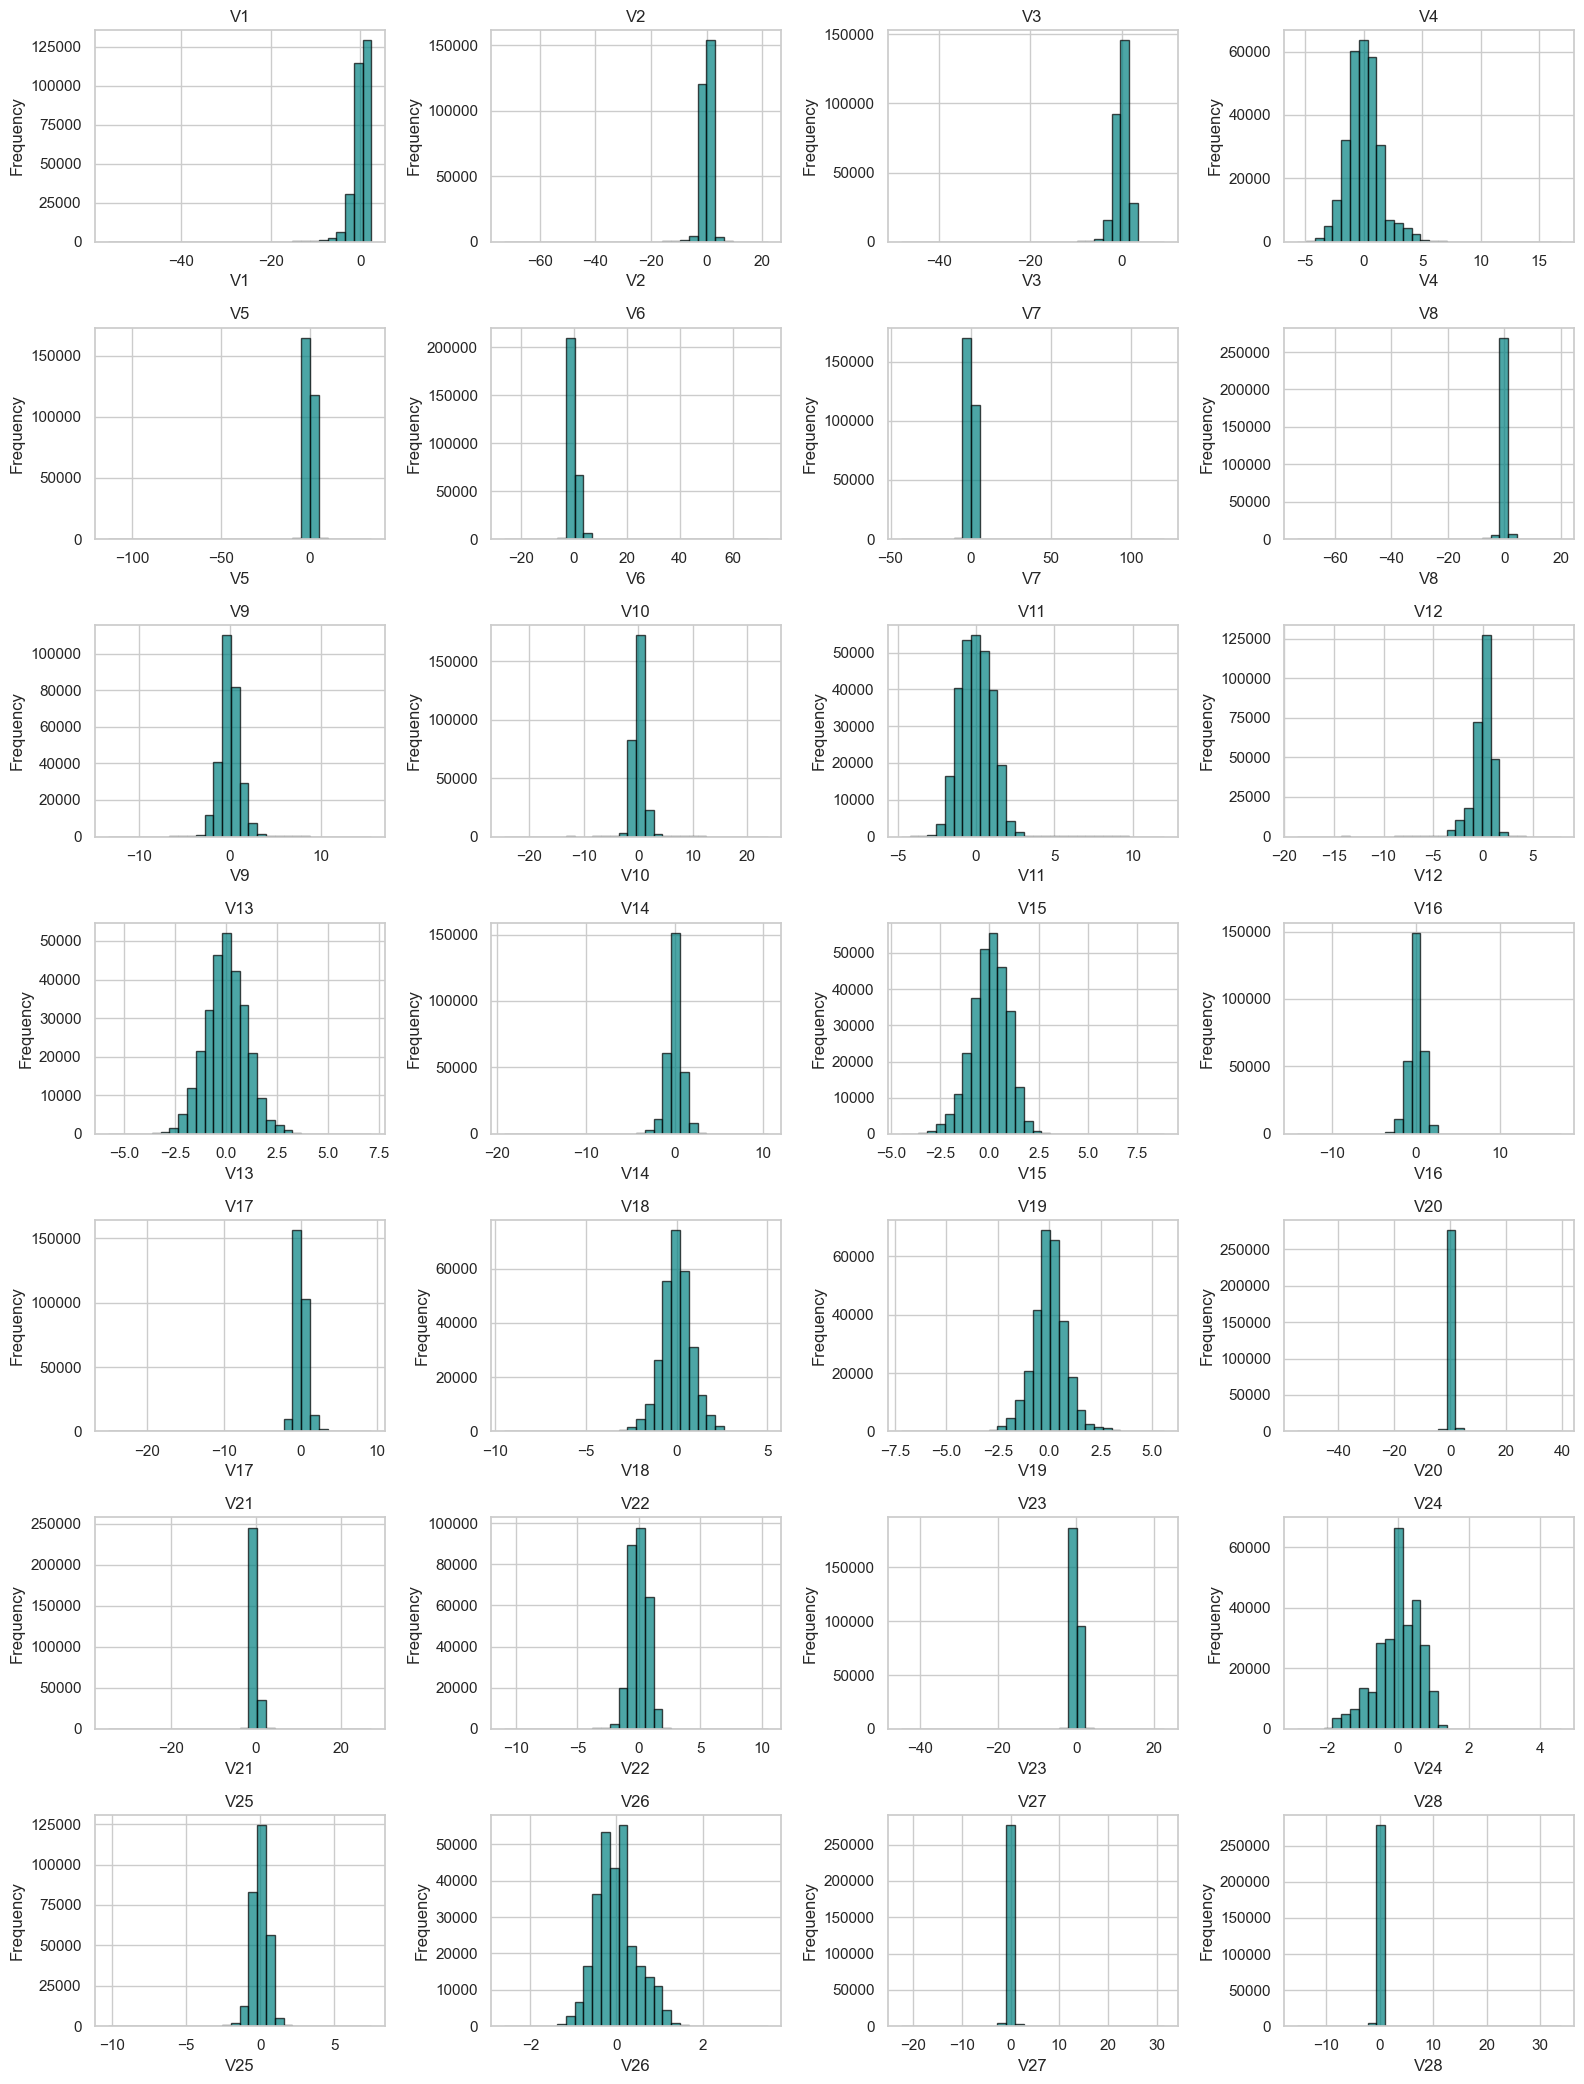

In [30]:
# List of columns you want to plot
features = [f"V{i}" for i in range(1, 29) if f"V{i}" in df_CreditCard_fraudDetection.columns]

n_features = len(features)
n_cols = 4  # number of columns in the grid
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(16, n_rows * 3))

for i, col in enumerate(features, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_CreditCard_fraudDetection[col], bins=30, color='teal', alpha=0.7, edgecolor='black')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

This histograms show that most features from **V1 to V28** are centered close to zero(0), but their distributions differ in spread, symmetry, and skewness. Some variables, such as **V4, V11, V13, V15, V18, V19, V24, and V26**, appear more smoothly distributed and closer to a bell-shaped pattern, while others, including **V1, V2, V5, V7, V8, V10, V12, V14, V16, V17, V20, V21, V23, V27, and V28**, are more sharply concentrated with narrower peaks and occasional long tails.

This suggests that the transformed features capture different underlying transaction patterns, with some variables showing stable central tendencies and others reflecting more extreme or irregular behavior. Overall, the distributions indicate that the feature space is not uniform, which supports the use of **Machine learning models** that can learn from varied feature behavior across multiple dimensions.

### Correlation Analysis

**Correlation between Target variable and Independent Variables.**

In [31]:
# Checking the correlation between features and the target.
cor = df_CreditCard_fraudDetection.corr()
cor

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


In [32]:
# Computing the correlation matrix
corr = df_CreditCard_fraudDetection.corr()

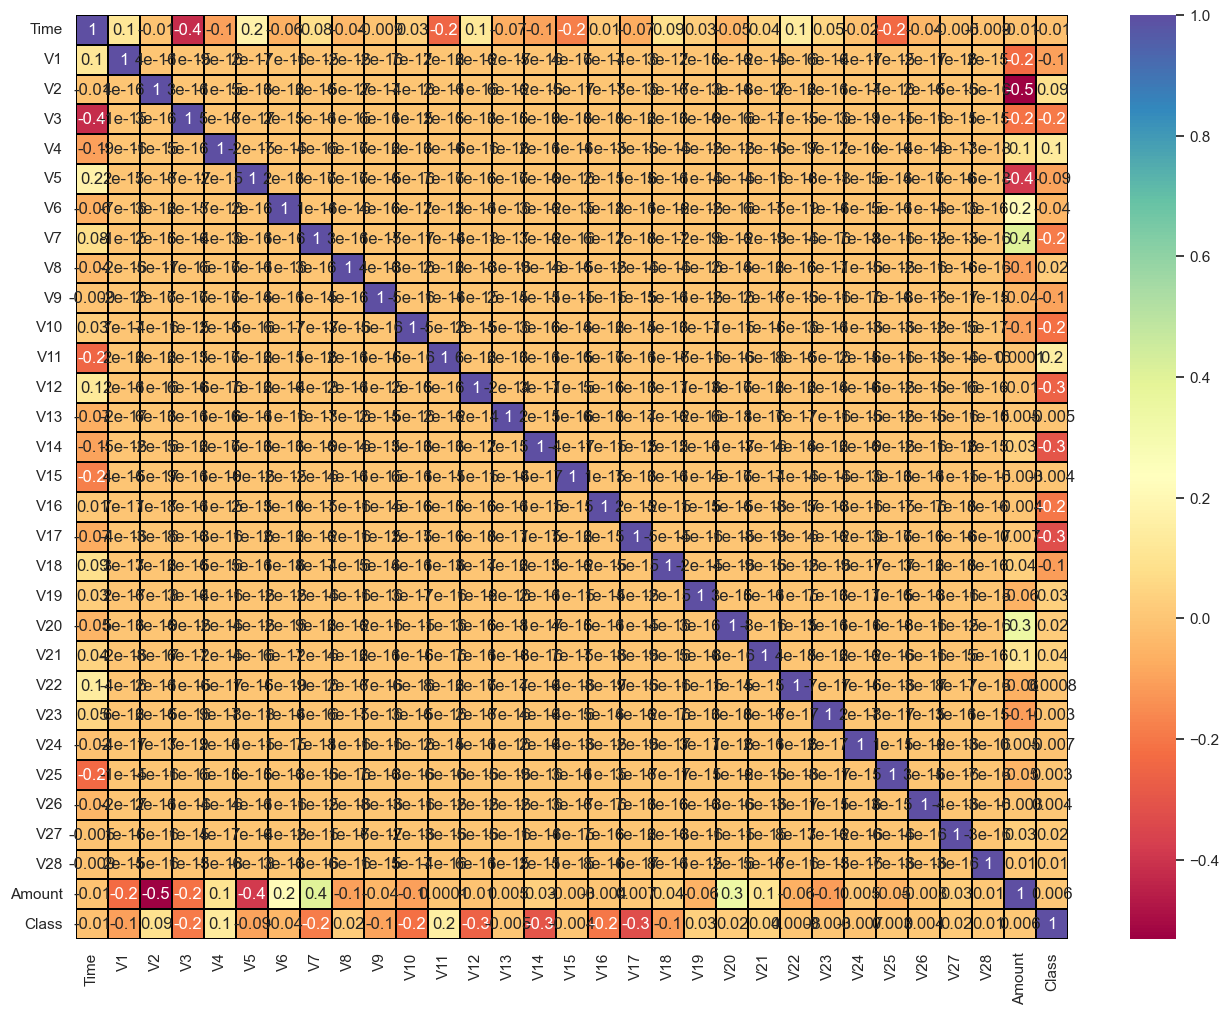

In [33]:
# Visualizing the correlation matrix by plotting heatmap
plt.figure(figsize = (16, 12))
sns.heatmap(df_CreditCard_fraudDetection.corr(), linewidths = 0.1, fmt = ".1g", linecolor = "black", annot = True, cmap = "Spectral")
plt.yticks(rotation = 0);
plt.show()

The correlation heatmap shows that most variables have **weak linear relationships** with one another, which is expected because the features **'V1' to 'V28'** are anonymized principal components. However, With respect to the target variable 'Class', a few features such as **V14, V12, V10, and V17** show relatively stronger negative(-ve) correlations, while **V11 and V4** show modest positive correlations.In all, this suggests that fraud detection is influenced by a small number of more informative transformed features rather than by strong correlations across the full feature set.


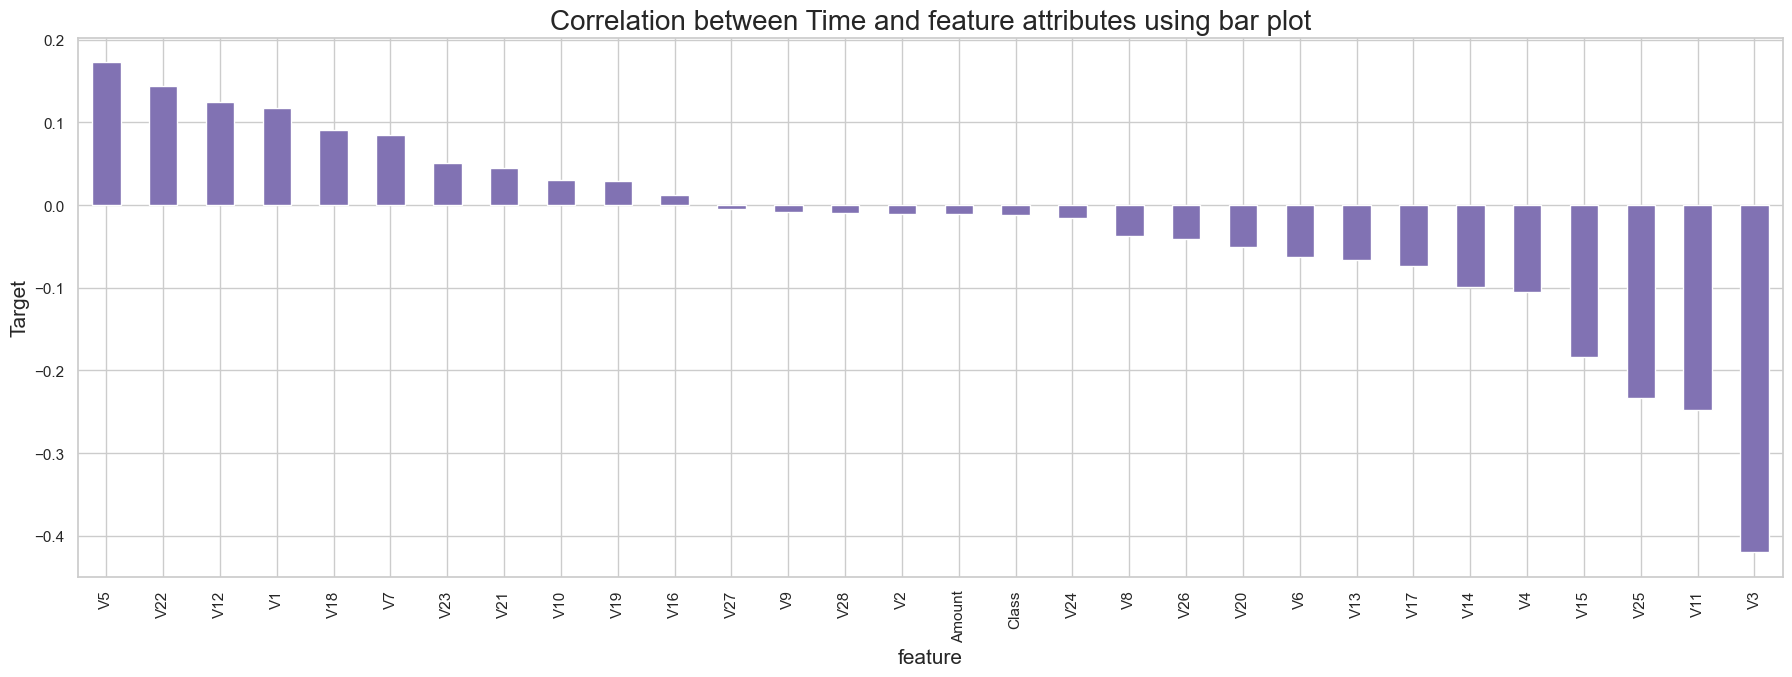

In [34]:
plt.figure(figsize = (22, 7))
df_CreditCard_fraudDetection.corr()['Time'].sort_values(ascending = False).drop(['Time']).plot(kind='bar',color="m")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between Time and feature attributes using bar plot", fontsize=20)
plt.show()

The bar plot indicates that **Time** has a very weak correlation with most of the feature variables. The strongest positive(+ve) relationships are seen with **V5, V22, V12, and V1**, while the strongest negative(-ve) relationships appear with **V3, V11, V25, and V15** which suggests that **transaction time** has some level of influence on certain transformed variables, but it is not a major independent predictor of fraud on its own.


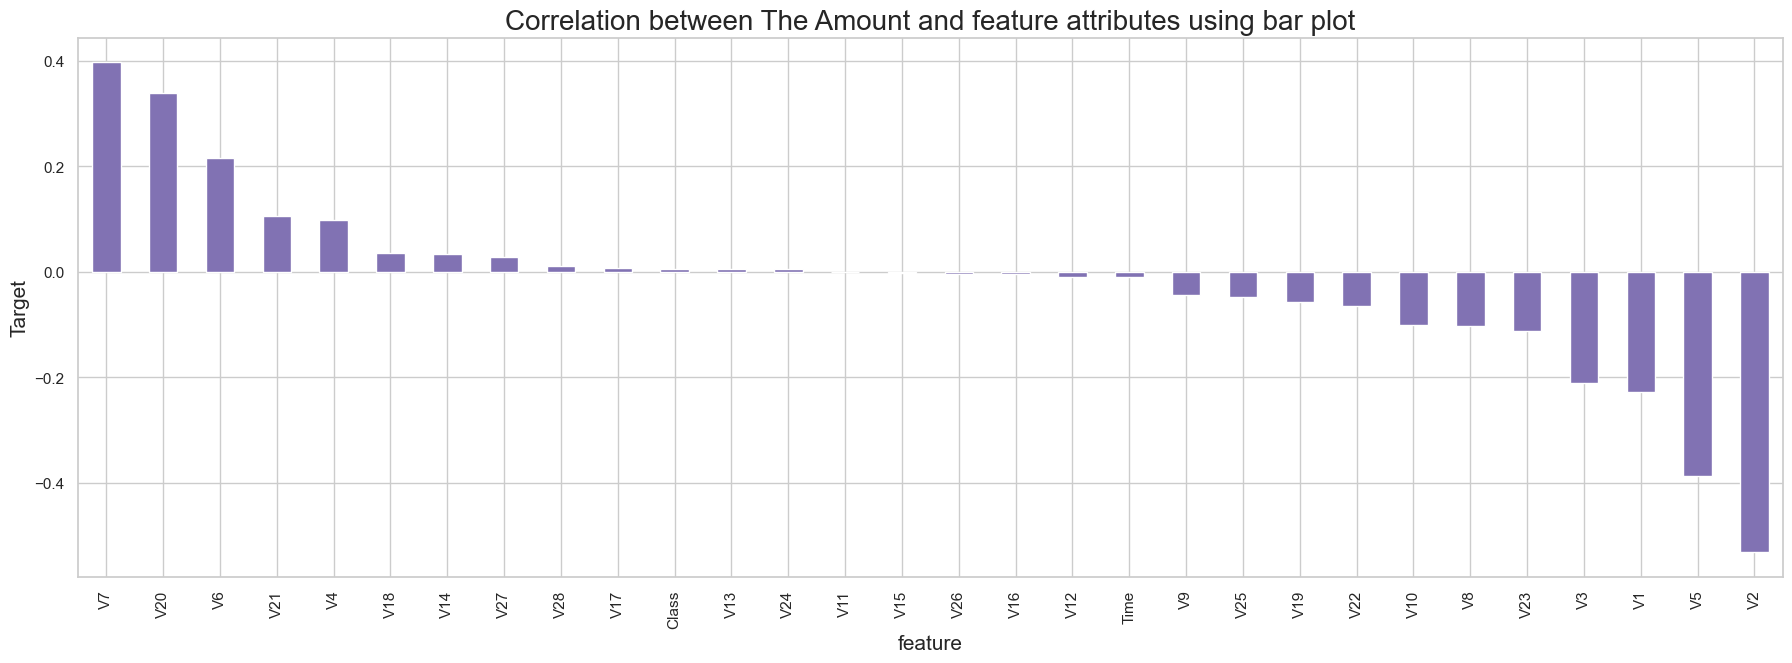

In [35]:
plt.figure(figsize = (22, 7))
df_CreditCard_fraudDetection.corr()['Amount'].sort_values(ascending = False).drop(['Amount']).plot(kind='bar',color="m")
plt.xlabel('feature', fontsize = 15)
plt.ylabel('Target', fontsize = 15)
plt.title("Correlation between The Amount and feature attributes using bar plot", fontsize=20)
plt.show()

This bar plot shows that **Amount** has slight positive(+ve) correlations with features **V7, V20, and V6**, while it has stronger negative(-ve) relationships with **V2, V5, and V1**. Most of the remaining features have correlations close to zero(0), indicating limited linear relationship with **transaction amount** which suggests that **transaction amount** is linked to a few key variables, but not broadly across all the feature variables.


**Checking for Skewness**

In [36]:
df_CreditCard_fraudDetection.skew()

Time      -0.035568
V1        -3.280667
V2        -4.624866
V3        -2.240155
V4         0.676292
V5        -2.425901
V6         1.826581
V7         2.553907
V8        -8.521944
V9         0.554680
V10        1.187141
V11        0.356506
V12       -2.278401
V13        0.065233
V14       -1.995176
V15       -0.308423
V16       -1.100966
V17       -3.844914
V18       -0.259880
V19        0.109192
V20       -2.037155
V21        3.592991
V22       -0.213258
V23       -5.875140
V24       -0.552499
V25       -0.415793
V26        0.576693
V27       -1.170209
V28       11.192091
Amount    16.977724
Class     23.997579
dtype: float64

The **Amount** and **V28**,  variable are significantly right skewed.We will use the cube root method to treat this skewness.

**Removing The Skewness**

In [37]:
# Removing skewness using the cuberoot method
df_CreditCard_fraudDetection['Amount'] = np .cbrt(df_CreditCard_fraudDetection['Amount'])
df_CreditCard_fraudDetection['V28'] = np .cbrt(df_CreditCard_fraudDetection['V28'])

We have now successfully removed the skewness using the cube root method.

In [38]:
# Let us Check the skewness once again
df_CreditCard_fraudDetection.skew()

Time      -0.035568
V1        -3.280667
V2        -4.624866
V3        -2.240155
V4         0.676292
V5        -2.425901
V6         1.826581
V7         2.553907
V8        -8.521944
V9         0.554680
V10        1.187141
V11        0.356506
V12       -2.278401
V13        0.065233
V14       -1.995176
V15       -0.308423
V16       -1.100966
V17       -3.844914
V18       -0.259880
V19        0.109192
V20       -2.037155
V21        3.592991
V22       -0.213258
V23       -5.875140
V24       -0.552499
V25       -0.415793
V26        0.576693
V27       -1.170209
V28       -0.256158
Amount     1.495629
Class     23.997579
dtype: float64

The above shows the decrease in the level of skewness.

**Visualizing the data distribution in the columns after skewness was removed**

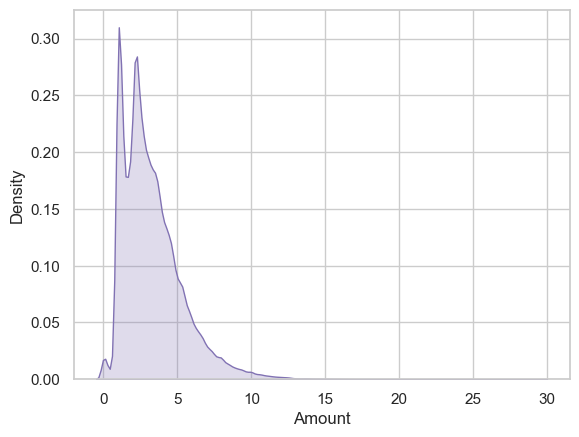

In [39]:
# Data distribution in Amount after skewness
sns.distplot(df_CreditCard_fraudDetection['Amount'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

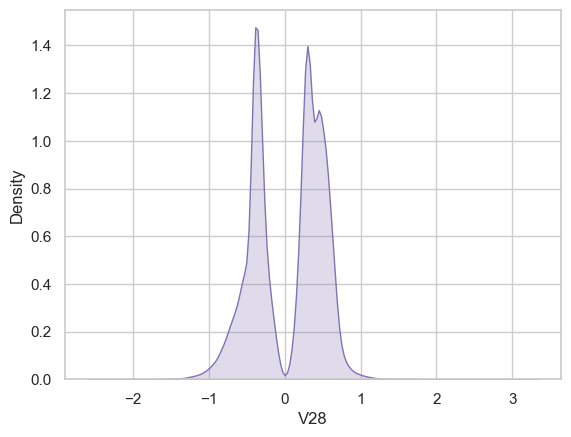

In [40]:
# Data distribution in V28 after skewness
sns.distplot(df_CreditCard_fraudDetection['V28'], color = "m", kde_kws = {"shade":True}, hist = False)
plt.show()

### Feature Engineering & Preprocessing

**Feature Scaling using standard scalarization**

Let's identify our independent variable (X) and dependant/target variable (y)

In [41]:
v_cols = [f"V{i}" for i in range(1, 29)]  # V1..V28
x = df_CreditCard_fraudDetection[['Time', 'Amount'] + v_cols].copy()
y = df_CreditCard_fraudDetection['Class'].astype(int)  

In [42]:
Scaler = StandardScaler()
x = pd.DataFrame(Scaler.fit_transform(x), columns = x.columns)
x

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,-1.996583,1.002517,-0.694242,-0.044075,1.672773,0.973366,-0.245117,0.347068,0.193679,0.082637,...,0.496282,0.326118,-0.024923,0.382854,-0.176911,0.110507,0.246585,-0.392170,0.330892,-0.683936
1,-1.996583,-0.908681,0.608496,0.161176,0.109797,0.316523,0.043483,-0.061820,-0.063700,0.071253,...,-0.179086,-0.089611,-0.307377,-0.880077,0.162201,-0.561131,0.320694,0.261069,-0.022256,0.446303
2,-1.996562,1.941925,-0.693500,-0.811578,1.169468,0.268231,-0.364572,1.351454,0.639776,0.207373,...,-2.778561,0.680975,0.337632,1.063358,1.456320,-1.138092,-0.628537,-0.288447,-0.137137,-0.932919
3,-1.996562,0.842090,-0.493325,-0.112169,1.182516,-0.609727,-0.007469,0.936150,0.192071,0.316018,...,-1.514205,-0.269855,-0.147443,0.007267,-0.304777,-1.941027,1.241904,-0.460217,0.155396,0.770551
4,-1.996541,0.423158,-0.591330,0.531541,1.021412,0.284655,-0.295015,0.071999,0.479302,-0.226510,...,0.987037,0.529939,-0.012839,1.100011,-0.220123,0.233250,-0.395202,1.041611,0.543620,1.214176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,1.641931,-1.139987,-6.065842,6.099286,-6.486245,-1.459641,-3.886611,-1.956690,-3.975628,6.116573,...,-0.838927,1.914365,0.290602,0.154146,1.624574,-0.841000,2.756320,0.518500,2.337901,1.947523
284803,1.641952,-0.164770,-0.374121,-0.033356,1.342145,-0.521651,0.629040,0.794446,0.019667,0.246886,...,-1.898626,0.077330,0.291625,1.273781,0.019958,-1.677920,-1.163726,-0.819647,0.169641,-0.902396
284804,1.641974,0.402751,0.980024,-0.182434,-2.143205,-0.393984,1.905833,2.275262,-0.239939,0.593140,...,-0.709121,0.001811,0.315913,0.796788,-0.060053,1.056944,0.509797,-0.181182,0.011037,-0.732162
284805,1.641974,-0.536163,-0.122755,0.321250,0.463320,0.487192,-0.273836,0.468155,-0.554672,0.568631,...,3.559840,0.165300,0.361112,1.102451,-0.261503,0.203428,-1.091855,1.133635,0.269604,0.936300


Standard Scalarization method was used on the dataset in order to guide against potential biases.

**Checking Variance Inflation Factor(VIF)**

In [43]:
# Finding variance inflation factor in each scaled column i.e.x.shape[1] (1/(1-R2))
vif = pd.DataFrame()
vif["VIF values"] = [variance_inflation_factor(x.values, i)
              for i in range(len(x.columns))]
vif["features"] = x.columns

vif

,VIF values,features
0,1.909715,Time
1,2.393420,Amount
2,1.079518,V1
3,1.655112,V2
4,1.373914,V3
5,1.022356,V4
6,1.321000,V5
7,1.089345,V6
8,1.106772,V7
9,1.009038,V8


Examinating the Variance Inflation Factor (VIF) allows us to identify features that contribute to multicollinearity problems.However, the above analysis shows that non of the feature have a VIF value exceeding **10**, meaning there are no strong correlation with other features.

### Balancing the Dataset Using SMOTE

In [44]:
y.value_counts()

0    284315
1       492
Name: Class, dtype: int64

Our observation as shown that there is an imbalance in the dataset.The objective of this project involves classification, the intention is to rectify this imbalance through the utilization of an oversampling technique known as the **SMOTE** in order to achieve a balanced dataset.

### Oversampling using SMOTE

In [45]:
# Oversampling the data 
SM = SMOTE()
x1,y1 = SM.fit_resample(x, y)

In [46]:
# checking the value count of target column
y.value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [47]:
sm = SMOTE(random_state=42) # In order to obtain same output 
x_res, y_res = sm.fit_resample(x, y)
y_res = pd.DataFrame(y_res)
print(y_res.value_counts())

Class
0        284315
1        284315
dtype: int64


Now that we have a balanced data, We can start building our Machine learning classification models .

## Machine Learning Models

#### SPLITTING INTO TRAIN AND TEST USING THE 70:30 RULE

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x_res,y_res,test_size=0.3,random_state=42,
                                                    shuffle=True,stratify=y_res)

### GENERATING THE ROC_AUC CURVE

In [49]:
# Plotting the ROC_AUC curve

def plot_roc_auc(y_test, preds):
    '''
    Takes actual and predicted(probabilities) as input and plots the Receiver
    Operating Characteristic (ROC) curve
    '''
    fpr, tpr, threshold = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

### Locating the best random state

In [50]:
# Base accuracy score should be better than always predicting the non-fraduelent

# Baseline accuracy = proportion of the majority class
counts = df_CreditCard_fraudDetection['Class'].value_counts()
baseline_acc = counts.max() / counts.sum() * 100
print(f"Baseline accuracy to beat: {baseline_acc:.2f}%")

Baseline accuracy to beat: 99.83%


### Short note on Base Accuracy Score

Most datasets on fraud tend to reveal their level of imbalance, where the non-fraudulent transactions highly outnumbers the fraudulent ones.Data should be balanced before modeling for accurate predictions.reason for computing the baseline accuracy which our models must outperform.

**Supervised Classification Models**

*  **Logistic Regression**

In [51]:
logr = LogisticRegression()

In [52]:
logr.fit(x_train, y_train)

LogisticRegression()

Classification Report (LR):
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     85295
           1       0.97      0.92      0.95     85294

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589

Confusion Matrix (LR):
 [[83226  2069]
 [ 6853 78441]]


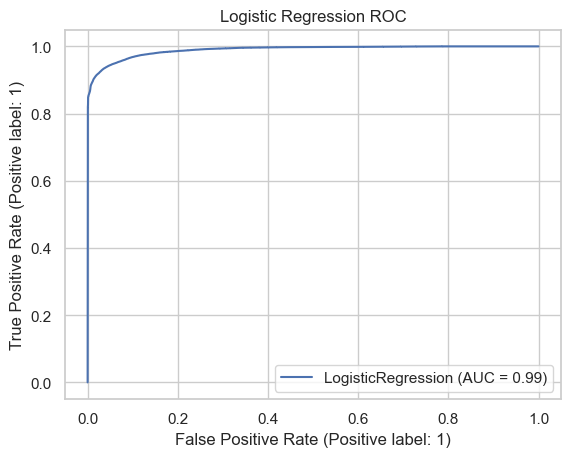

In [53]:
# y_test, X_test, logr must exist (logr is your trained LogisticRegression)
print("Classification Report (LR):\n", classification_report(y_test, logr.predict(x_test)))
print("Confusion Matrix (LR):\n", confusion_matrix(y_test, logr.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(logr, x_test, y_test)
plt.title("Logistic Regression ROC")
plt.show()

The **Logistic Regression** model shows strong classification performance, with an **AUC of 99%**, indicating excellent ability to distinguish fraudulent from non-fraudulent transactions. The model achieved **95% accuracy**, with balanced **precision, recall, and F1-score of 95%**, showing consistent performance across both classes.

From the confusion matrix, the model correctly classified most transactions, with **83,226 true negatives(-ves)** and **78,441 true positives(+ve)**. However, it also produced **2,069 false positives(+ves)** and **6,853 false negatives(-ves)**, meaning some fraudulent cases were still missed. Hence, the above results suggest that Logistic Regression performs very well for fraud detection, though reducing false negatives(-ves) would further improve its practical effectiveness.


* **Random Forest**

In [54]:
RandFor = RandomForestClassifier()

In [55]:
RandFor.fit(x_train, y_train)

RandomForestClassifier()

Classification Report (RF):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       1.00      1.00      1.00     85294

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589

Confusion Matrix (RF):
 [[85276    19]
 [    0 85294]]


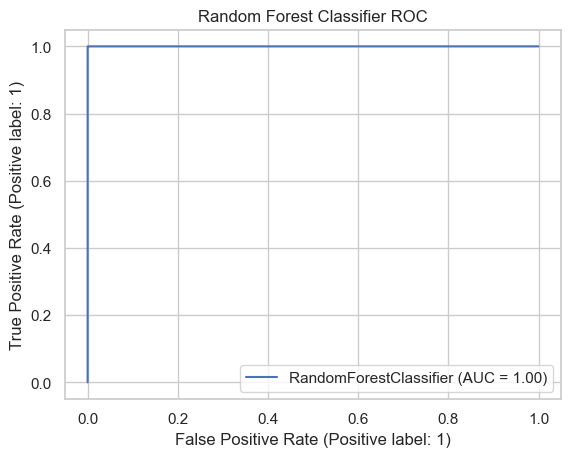

In [56]:
# y_test, X_test,while RandFor exists has our trained Random Forest Classifier)
print("Classification Report (RF):\n", classification_report(y_test, RandFor.predict(x_test)))
print("Confusion Matrix (RF):\n", confusion_matrix(y_test, RandFor.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(RandFor, x_test, y_test)
plt.title("Random Forest Classifier ROC")
plt.show()

The **Random Forest Classifier** achieved near-perfect performance, with an **AUC of 100%** and overall **accuracy of 1.00**, indicating exceptional ability to distinguish fraudulent from non-fraudulent transactions. The classification report shows precision, recall, and F1-score of **1.00** for both classes, reflecting highly balanced and consistent **predictive performance**.

The confusion matrix further confirms this result, with **85,276 true negatives(-ves)** and **85,294 true positives(+ves)** correctly identified. The model produced only **19 false positives(+ves)** and **no/(0) false negatives(-ves)**, meaning it almost never misclassified legitimate transactions and did not miss any fraudulent cases in the test set. Overall, the Random Forest model demonstrates outstanding effectiveness for **fraud detection** and performs substantially better than Logistic Regression.


* **XGBoost(Extreme Gradient Boosting) Classifier**

In [57]:
XGB = XGBClassifier()

In [58]:
XGB.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

Classification Report (XG):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       1.00      1.00      1.00     85294

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589

Confusion Matrix (XG):
 [[85243    52]
 [    0 85294]]


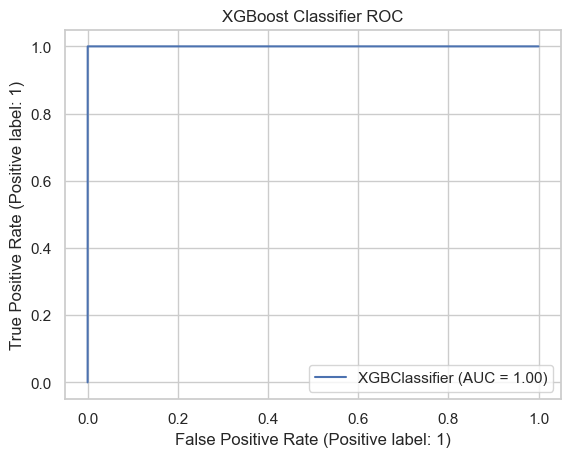

In [59]:
y_pred = XGB.predict(x_test)

# y_test, X_test, while the XGB is our trained XGBClassifier)
print("Classification Report (XG):\n", classification_report(y_test, XGB.predict(x_test)))
print("Confusion Matrix (XG):\n", confusion_matrix(y_test, XGB.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(XGB, x_test, y_test)
plt.title("XGBoost Classifier ROC")
plt.show()

The accuracy score and AUC using XGBoost Classifier is 100% respectively.

The **XGBoost Classifier** also delivered outstanding performance, with an **AUC of 1.00** and overall **accuracy of 1.00**, showing an excellent ability to distinguish **fraudulent from non-fraudulent transactions**. The classification report indicates precision, recall, and F1-score of **1.00** for both classes, confirming highly balanced and reliable classification performance.

The confusion matrix shows that the model correctly identified **85,243 legitimate transactions** and **85,294 fraudulent transactions**. It produced only **52 false positives(+ves)** and **no/(0) false negatives(-ves)**, meaning it successfully detected every fraudulent case in the test set while making very few mistakes on legitimate transactions.Hence, the XGBoost demonstrates extremely strong fraud detection capability and performs at a level very close to the Random Forest model.


* **Support Vector Machine (SVM)**

In [60]:
svm_classifier = SVC()

In [61]:
svm_classifier.fit(x_train, y_train)

SVC()

Classification Report (SVC):
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     85295
           1       0.99      0.98      0.98     85294

    accuracy                           0.98    170589
   macro avg       0.98      0.98      0.98    170589
weighted avg       0.98      0.98      0.98    170589

Confusion Matrix (SVC):
 [[84048  1247]
 [ 1877 83417]]


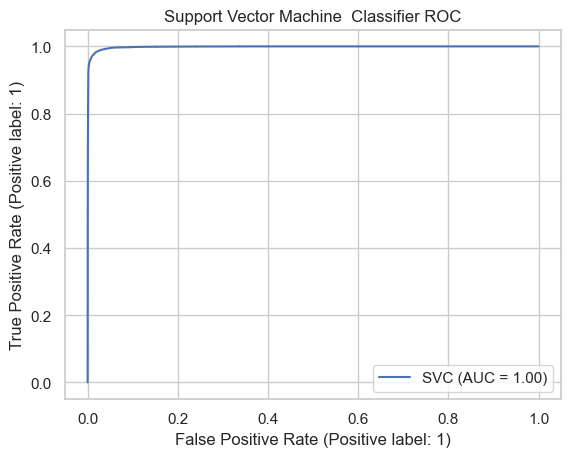

In [62]:
# y_test, X_test,while SVC exists has our trained Support Vector Machine  Classifier)
print("Classification Report (SVC):\n", classification_report(y_test, svm_classifier.predict(x_test)))
print("Confusion Matrix (SVC):\n", confusion_matrix(y_test, svm_classifier.predict(x_test)))

# ROC curve in one line
RocCurveDisplay.from_estimator(svm_classifier, x_test, y_test)
plt.title("Support Vector Machine  Classifier ROC")
plt.show()

The **Support Vector Machine Classifier** achieved very strong performance, with an **AUC of 1.00** and overall **accuracy of 98%**, indicating excellent separation between **fraudulent and non-fraudulent transactions**. The classification report shows **precision, recall, and F1-score of 98%** for both classes, reflecting balanced and reliable predictive performance.

From the confusion matrix, the model correctly classified **84,048 legitimate transactions** and **83,417 fraudulent transactions**. It also produced **1,247 false positives(+ves)** and **1,877 false negatives(-ves)**, meaning a small number of legitimate transactions were flagged incorrectly and some fraud cases were missed.Hence, the SVM model performs very well, though it is slightly less effective than the Random Forest and XGBoost models.


### Model Predictions

In [63]:
# Saving the model using .pkl
import joblib
joblib.dump(logr, "Anomaly Detection in Credit Card Fraud.pki")

['Anomaly Detection in Credit Card Fraud.pki']

**Prediction On The Train Data**

In [64]:
modelname = LogisticRegression()

In [65]:
# Training the model on the training data
modelname.fit(x_train, y_train)

LogisticRegression()

In [66]:
# Lets load the saved model and get the predictions
Logr = joblib.load("Anomaly Detection in Credit Card Fraud.pki")

# prediction
prediction = Logr.predict(x_train)
prediction

array([1, 0, 1, ..., 0, 0, 0])

Above are the predicted Credit Card fraud on the train data.

In [67]:
a = np.array(y_train)
df_CreditCard_fraudDetection_train = pd.DataFrame()
df_CreditCard_fraudDetection_train["predicted"] = prediction
df_CreditCard_fraudDetection_train["original"] = a
df_CreditCard_fraudDetection_train

,predicted,original
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1
...,...,...
398036,0,0
398037,1,1
398038,0,0
398039,0,0


**Prediction On The Test Data**

In [68]:
 # Make predictions on the test data
predictions = modelname.predict(x_test)

In [69]:
# diagnostics
print("raw shapes:", np.shape(predictions), np.shape(y_test))

raw shapes: (170589,) (170589, 1)


In [70]:
# convert predictions -> 1D labels
pred_arr = np.asarray(predictions)
if pred_arr.ndim == 2:
    # if probabilities (two columns), take class with highest score
    if pred_arr.shape[1] == 1:
        pred_arr = pred_arr.ravel()
    else:
        # common case: class probs for binary -> take positive class
        # adjust as needed: use argmax for multiclass
        pred_arr = np.argmax(pred_arr, axis=1)

preds = pred_arr.ravel()

In [71]:
# convert y_test -> 1D
if isinstance(y_test, pd.DataFrame):
    y_true = y_test.squeeze().values
else:
    y_true = np.asarray(y_test).ravel()

In [72]:
# check shapes
if preds.shape[0] != y_true.shape[0]:
    raise ValueError(f"Length mismatch: preds={preds.shape[0]} vs y_true={y_true.shape[0]}")

In [73]:
# final DataFrame
conclusion = pd.DataFrame({'Predicted': preds, 'Original': y_true})
print(conclusion.shape)
conclusion.head()

(170589, 2)


,Predicted,Original
0,1,1
1,0,0
2,0,0
3,0,0
4,0,0


In [74]:
print(conclusion)

        Predicted  Original
0               1         1
1               0         0
2               0         0
3               0         0
4               0         0
...           ...       ...
170584          0         0
170585          0         0
170586          1         1
170587          0         0
170588          0         0

[170589 rows x 2 columns]


### Summary and Conclusion

**Summary**

This project focused on detecting fraudulent credit card transactions using **Machine learning (ML)** on a highly imbalanced dataset of **284,807** transactions, including **492** fraud cases. It was framed as a **binary classification problem** using transaction features such as **'Time', 'Amount', and 'V1' to 'V28'**, with the goal of accurately identifying fraud while minimizing false negatives(-ves). **Exploratory analysis** showed that the dataset was complete, heavily imbalanced, and dominated by lower-value transactions, making fraud detection both challenging and operationally important.  

Multiple models were evaluated, including **Logistic Regression, Random Forest, XGBoost, and Support Vector Machine(SVC)**. **Logistic Regression** performed strongly, achieving **95% accuracy** and an **AUC of 99%**, but it still missed a notable number of fraudulent cases. In contrast, **Random Forest and XGBoost** delivered near-perfect results, with accuracy and AUC of **100%** and almost no misclassifications, while **SVM** also performed very well with **98%** accuracy and an AUC of **100%**.    

**Conclusion**

The project demonstrates that **Machine learning(ML)** can be highly effective for **credit card fraud detection**, even in the presence of severe class imbalance. Among the evaluated models, **Random Forest and XGBoost** produced the strongest results, showing exceptional ability to distinguish **fraudulent from legitimate transactions** while keeping classification errors extremely low. These findings indicate that **advanced ensemble methods** are especially well suited for **fraud detection** tasks where precision and recall are both critical.  

In conclusion, this analysis confirms that **predictive modeling** can provide strong support for **financial fraud prevention** by improving detection accuracy and reducing missed fraud cases. The project also shows the importance of comparing multiple algorithms, since simpler models such as Logistic Regression performed well, but more advanced models achieved substantially better fraud detection outcomes. 


### The End